In [1]:
import pandas as pd

# 1. CREATE DUMMY DATASET (As permitted by image_5c63b5.png)
# We create a dictionary containing typical vehicle email examples
raw_data = {
    'email_text': [
        'Get cheap vehicle insurance now! Click here.',
        'Hi, your car service appointment is confirmed for Tuesday.',
        'WIN A FREE NEW CAR!!! Call this number immediately!!',
        'Can you send over the vehicle registration documents?',
        'RE: Update on your car loan application status.',
        'URGENT: Your vehicle warranty has expired! Pay now to renew.',
        None, # An intentional missing value to demonstrate cleaning
        '   Check out these cheap vehicle accessories!!!   ' # Extra spaces
    ],
    'label': ['spam', 'ham', 'spam', 'ham', 'ham', 'spam', 'spam', 'spam']
}

# Convert this dictionary into a Pandas DataFrame table
df = pd.DataFrame(raw_data)

# 2. --- PERFORM: DATA CLEANING ---
# Rule A: Remove rows with missing text values (NaN)
df.dropna(inplace=True)

# Rule B: Remove trailing white spaces from the text
df['email_text'] = df['email_text'].str.strip()

# Rule C: Convert all text to lowercase so the AI treats "CAR" and "car" identically
df['cleaned_text'] = df['email_text'].str.lower()

# 3. SAVE TO DATA FOLDER
# This fulfills the "Dataset Files" upload requirement
df.to_csv('../data/vehicle_emails.csv', index=False)

print("Data Cleaning Complete! Cleaned Dataset Saved to /data/ folder.")
print(df[['cleaned_text', 'label']])

Data Cleaning Complete! Cleaned Dataset Saved to /data/ folder.
                                        cleaned_text label
0       get cheap vehicle insurance now! click here.  spam
1  hi, your car service appointment is confirmed ...   ham
2  win a free new car!!! call this number immedia...  spam
3  can you send over the vehicle registration doc...   ham
4    re: update on your car loan application status.   ham
5  urgent: your vehicle warranty has expired! pay...  spam
7       check out these cheap vehicle accessories!!!  spam


--- Data Analysis Insights ---
label
ham     8.333333
spam    8.000000
Name: word_count, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_1752\1247254913.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


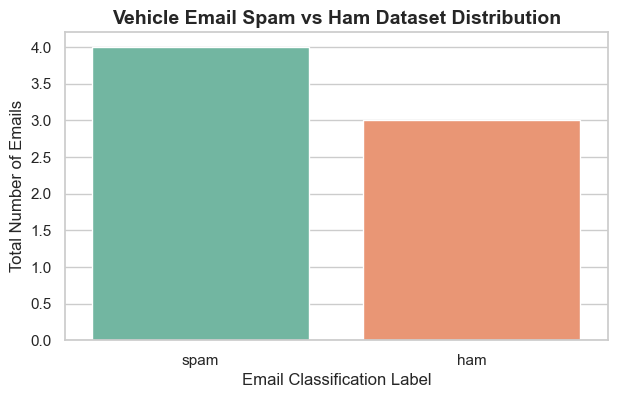

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. --- PERFORM: ANALYSIS ---
# Calculate the word count of each email to see if spam emails are longer/shorter
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

print("--- Data Analysis Insights ---")
print(df.groupby('label')['word_count'].mean())

# 2. --- PERFORM: VISUALIZATION (GRAPHS & CHARTS) ---
# Set up a clean, modern style for our plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

# Create a bar chart counting the total number of Spam vs Ham emails
sns.countplot(x='label', data=df, palette='Set2')

# Customize chart text labels
plt.title('Vehicle Email Spam vs Ham Dataset Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Email Classification Label', fontsize=12)
plt.ylabel('Total Number of Emails', fontsize=12)

# Save the visualization directly to your output folder for submission
plt.savefig('../output/spam_distribution_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import joblib

X = df['cleaned_text']
y = df['label']

# Vectorization processing
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X)

# --- PERFORM: PREDICTION MODELS ---
model = MultinomialNB()
model.fit(X_tfidf, y)

# Save the binaries so the dashboard application can access them
joblib.dump(model, '../src/spam_model.pkl')
joblib.dump(vectorizer, '../src/vectorizer.pkl')

print("🧠 AI Prediction Model trained and saved successfully into /src/ folder!")

🧠 AI Prediction Model trained and saved successfully into /src/ folder!
